
# Handwritten Digit Recognition using Neural Networks

This project uses the MNIST handwritten digits dataset to build a neural network using TensorFlow and Keras.

## Project Goals
- Understand image data
- Preprocess and normalize images
- Flatten image matrices into vectors
- Build a simple neural network
- Evaluate model performance
- Improve the model using a hidden layer

This notebook is beginner-friendly and explains each step clearly.


# 1. Importing Libraries

In [20]:
# Import TensorFlow and Keras for building neural networks
import tensorflow as tf
from tensorflow import keras

# Import Matplotlib for image visualization
import matplotlib.pyplot as plt

# Display plots directly inside the notebook
%matplotlib inline

# Import NumPy for numerical operations
import numpy as np

# 2. Loading the MNIST Dataset

In [41]:
# Load the MNIST handwritten digits dataset

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# 3. Inspecting the Dataset

In [44]:
# Inspecting the Data

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


60,000 training images
each image is 28×28 pixels

# 4. Displaying a Sample Image

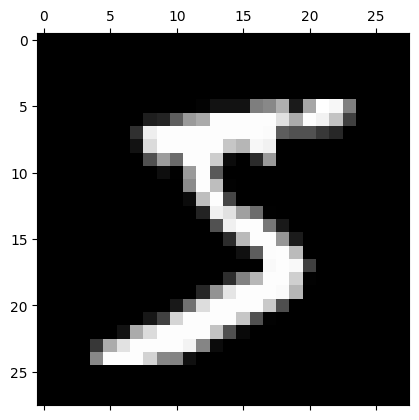

 X_train[0] = 5


In [51]:
#Displaying an Image
plt.matshow(X_train[0], cmap='gray')
plt.show()
print(f" X_train[0] = {y_train[0]}")

# 5. Normalizing the Data

In [52]:
# Normalizing the Data
# Convert pixel values from 0-255 into 0-1

X_train = X_train / 255
X_test = X_test / 255

# 6. Flattening the Images


The neural network cannot directly understand a 28×28 image matrix.

We flatten the image:

28 × 28 → 784

This converts every image into one long vector containing 784 pixel values.


In [53]:
# Flatten the Images Manually
#The neural network cannot directly understand a 28x28 image matrix.
#We must convert:   28×28→784

# Flatten the training images

X_train_flattened = X_train.reshape(len(X_train), 28 * 28)

# Flatten the testing images

X_test_flattened = X_test.reshape(len(X_test), 28 * 28)


# 7. Checking the New Shape

In [55]:
# Print the new shape after flattening

print(X_train_flattened.shape)
print(X_test_flattened.shape)

# each image is now one long list containing 784 numbers

(60000, 784)
(10000, 784)


# 8. Building the First Neural Network (No Hidden Layer)


This is the simplest neural network architecture in the project.

Architecture:

784 → 10

- 784 input values (pixels)
- 10 output neurons (digits 0–9)

There is no hidden layer in this first model.


In [60]:
# Build the First Neural Network (No Hidden Layer) ==> 784 → 10

model = keras.Sequential([

    # Output layer with 10 neurons
    # One neuron for each digit (0-9)

    keras.layers.Dense( 10, input_shape=(784,), activation='sigmoid')
        
        ])


# 9. Compiling the Model

In [61]:
# Configure the learning process

model.compile(

    # Adam optimizer adjusts the weights efficiently
    optimizer='adam',

    # Loss function measures prediction error
    loss='sparse_categorical_crossentropy',

    # Show accuracy while training
    metrics=['accuracy']
)

# 10. Training the Model

In [62]:
# Train the neural network

# The model:
# 1. Looks at the images
# 2. Makes predictions
# 3. Compares predictions with correct answers
# 4. Adjusts itself to improve accuracy

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.8814 - loss: 0.4622
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step - accuracy: 0.9151 - loss: 0.3038
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.9210 - loss: 0.2832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step - accuracy: 0.9231 - loss: 0.2735
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 508us/step - accuracy: 0.9253 - loss: 0.2668


# 11. Evaluating the Model

In [63]:
# evaluating the model
# Test the model on unseen data

model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.9256 - loss: 0.2658


[0.26583483815193176, 0.925599992275238]

# 12. Making Predictions

In [75]:
# Predict all test images
predictions = model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step


# 13. Understanding Model Output

In [99]:
# The model returns probability scores for each digit

# Example:
# [0.01, 0.02, 0.95, ...]

# The largest value represents the predicted digit

predictions[0]

array([2.1300057e-02, 5.4975555e-07, 6.4342864e-02, 9.7156984e-01,
       2.2757293e-03, 1.0112761e-01, 1.5866250e-06, 9.9972165e-01,
       8.2475960e-02, 7.0896721e-01], dtype=float32)

# 14. Predicting a Single Digit

In [100]:
predicted_digit = np.argmax(predictions[0])
print(predicted_digit)

7


# 15. Converting Predictions into Labels

In [106]:
y_predicted = [np.argmax(i) for i in predictions]
y_predicted[0]

np.int64(7)

# 16. Visualizing a Test Image

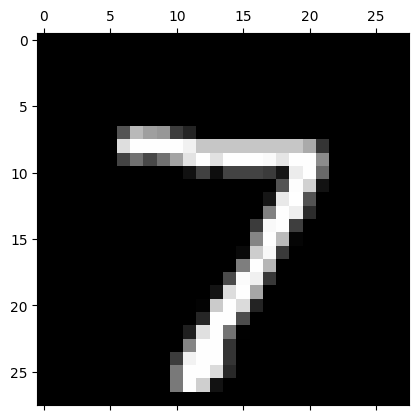

In [101]:
plt.matshow(X_test[0],cmap = 'gray')

# 17. Creating a Confusion Matrix


Now we improve the neural network by adding a hidden layer.

New architecture:

784 → 100 → 10

The hidden layer helps the model learn more complex patterns and improves accuracy.


Text(50.722222222222214, 0.5, 'True')

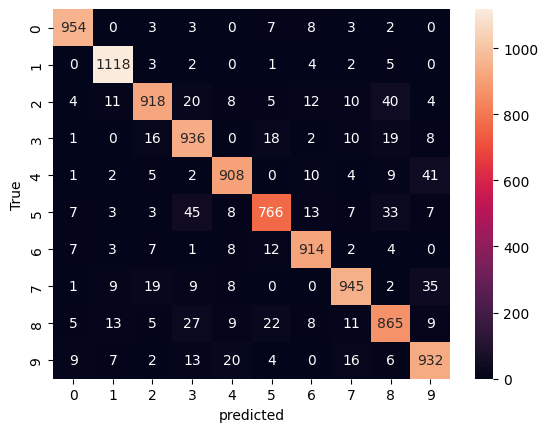

In [115]:
# Create a confusion matrix

# A confusion matrix helps visualize:
# - Correct predictions
# - Incorrect predictions
# - Which digits the model confuses most often

cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted)

import seaborn as sn

plt.figure(figsize=(10, 7))

sn.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

# 18. Building an Improved Neural Network

In [126]:
# Now we create a more powerful neural network using a hidden layer
model_2 = keras.Sequential([
    
        #hidden layer with  100 neurons
        keras.layers.Dense(100, input_shape = (784,), activation = 'relu'),
        #output layer
        keras.layers.Dense(10,activation='sigmoid')
        
        
    
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

#training the model

model_2.fit(X_train_flattened,y_train,epochs=5)

/opt/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - accuracy: 0.9214 - loss: 0.2714
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 890us/step - accuracy: 0.9646 - loss: 0.1211
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - accuracy: 0.9750 - loss: 0.0828
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - accuracy: 0.9805 - loss: 0.0642
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 948us/step - accuracy: 0.9851 - loss: 0.0495


# 19. Evaluating the Improved Model

In [127]:
# evaluating the model on the test set
model_2.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.9756 - loss: 0.0836


[0.08362209796905518, 0.975600004196167]

# 20. Predicting Using the Improved Model

In [129]:
predictions2 = model_2.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step


# 21. Converting Improved Predictions

In [130]:
y_predicted_2 = [np.argmax(i) for i in predictions2]

# 22. Improved Confusion Matrix

Text(50.722222222222214, 0.5, 'True')

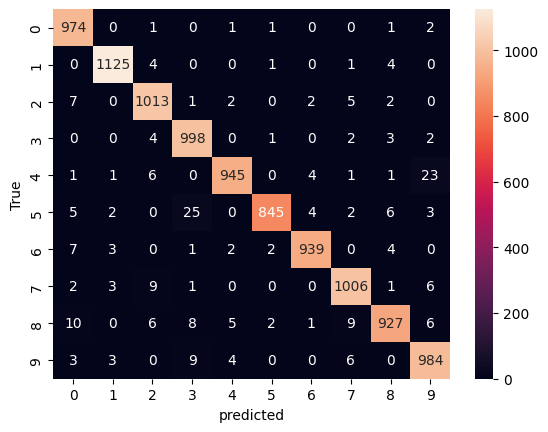

In [135]:
cm2 = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_2)
sn.heatmap(cm2,annot=True,fmt = 'd')
plt.xlabel('predicted')
plt.ylabel('True')


# Final Results

In this project, we successfully:

- Loaded and explored the MNIST dataset
- Normalized image data
- Flattened images into vectors
- Built a neural network without a hidden layer
- Improved the model using a hidden layer
- Evaluated model performance using confusion matrices

This project demonstrates the foundations of neural networks and image classification using TensorFlow and Keras.
